In [46]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import warnings
warnings.filterwarnings('ignore')

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1-Read a data


In [48]:
file_path = "/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv"

data = pd.read_csv(file_path , index_col = 'Time')

## 2-Preprocessing

In [49]:
print(data['Class'].value_counts())

print("\nPercentage:")
print(data['Class'].value_counts(normalize=True))

Class
0    284315
1       492
Name: count, dtype: int64

Percentage:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


## 3-EDA


### 3.1 Feature Distribution Analysis (Skewness Investigation)
To design an effective preprocessing pipeline, we need to inspect the distribution of our continuous features. Visualizing key features like `V1` (as a representative of the PCA components) and `Amount` (the transaction value) reveals a highly skewed distribution. 

<Axes: xlabel='Amount', ylabel='Density'>

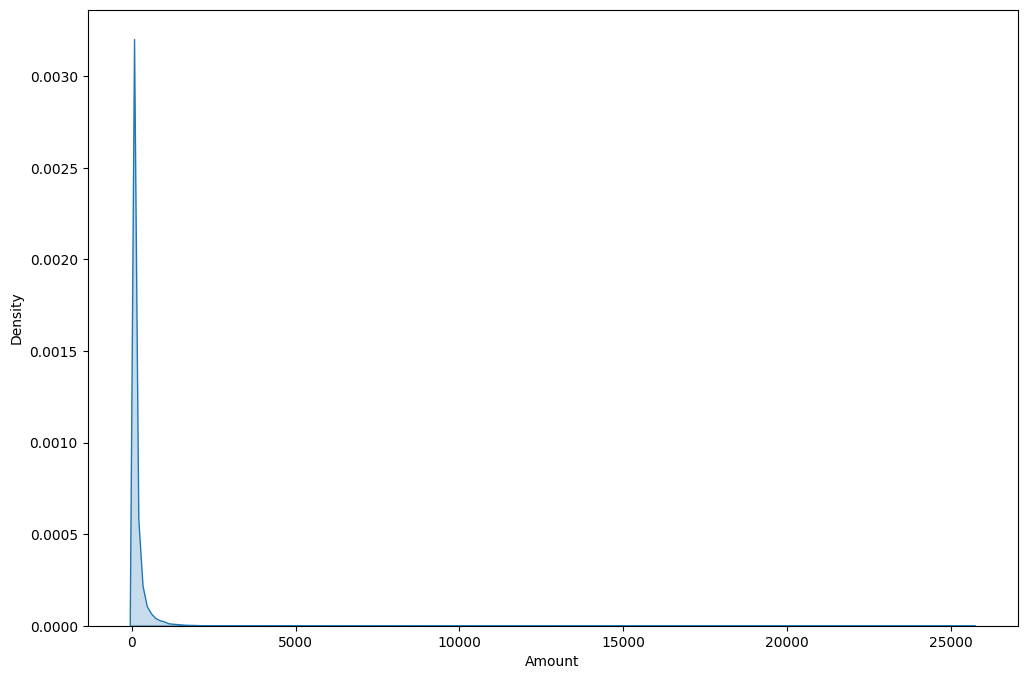

In [50]:
plt.figure(figsize = (12,8))
sns.kdeplot(data = data['Amount'] , shade = True)

<Axes: xlabel='V1', ylabel='Density'>

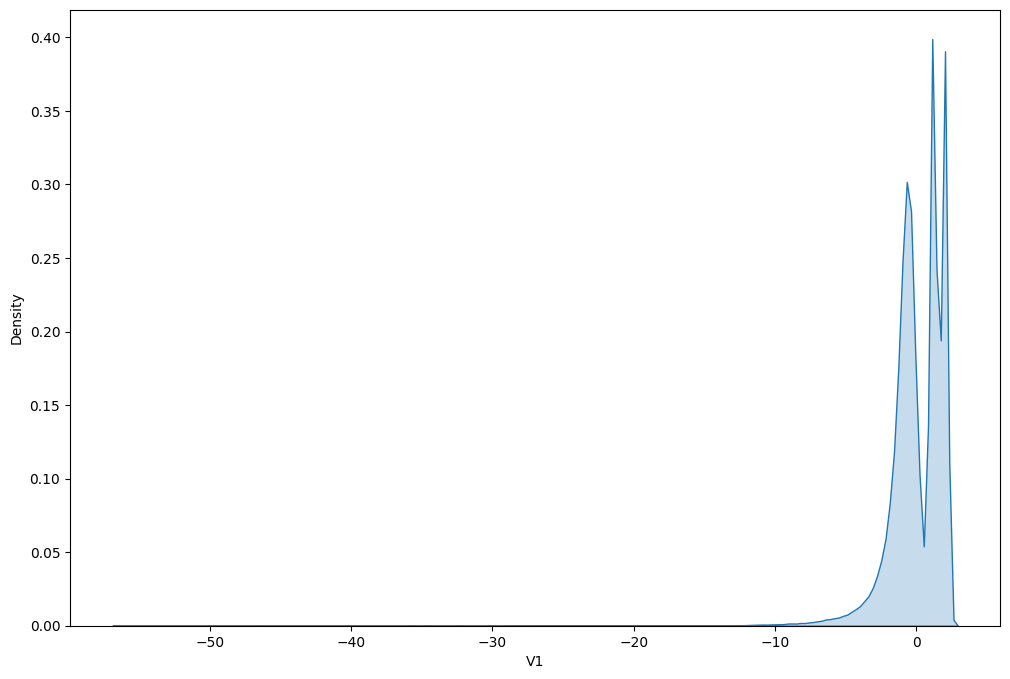

In [51]:
plt.figure(figsize = (12,8))
sns.kdeplot(data = data['V1'] , shade = True)

Severe skewness can negatively affect model convergence and performance, making data transformation a critical step before feeding the features into our classifiers.

In [52]:
X = data.drop('Class' , axis = 1)
y = data['Class']

## 4-Data Preprocessing & Feature Engineering


In [53]:
from sklearn.model_selection import train_test_split

X_train , X_data , y_train , y_data = train_test_split(X , y, test_size= 0.2 , random_state = 42 , stratify = y)

X_valid , X_test , y_valid , y_test = train_test_split(X_data , y_data , test_size = 0.5 , random_state = 42 , stratify = y_data)

### 4.1 Mitigating Skewness using PowerTransformer
To address the extreme skewness observed in features like `Amount` and the `V` components, we apply `PowerTransformer` with the **Yeo-Johnson** method. This transformation stabilizes variance and minimizes skewness, mapping the data closer to a normal (Gaussian) distribution.

To prevent **Data Leakage**, we strictly `fit_transform` on the training set and only `transform` the validation and test sets.

In [54]:
from sklearn.preprocessing import PowerTransformer

scaler = PowerTransformer(method='yeo-johnson')

X_train_final_t = scaler.fit_transform(X_train)

X_valid_final_t = scaler.transform(X_valid)
X_test_final_t = scaler.transform(X_test)  

X_train_final = pd.DataFrame(X_train_final_t , columns = X_train.columns)
X_valid_final = pd.DataFrame(X_valid_final_t , columns = X_valid.columns)
X_test_final = pd.DataFrame(X_test_final_t , columns = X_test.columns)


We want to verify whether the proportions of y = 1 in the test and training sets are the same.

In [55]:
print(f"Fruad percentege in tranining set : {y_train.mean()}")
print(f"Fruad percentege in validation set : {y_valid.mean()}")
print(f"Fruad percentege in test set : {y_test.mean()}")


Fruad percentege in tranining set : 0.001729245759178389
Fruad percentege in validation set : 0.0017204452090867595
Fruad percentege in test set : 0.0017204452090867595


They have a very slight difference, but it's acceptable.

In [56]:
X_train_final['Amount'].describe()

count    2.278450e+05
mean     4.089024e-16
std      1.000002e+00
min     -2.012876e+00
25%     -7.480678e-01
50%      2.608875e-02
75%      7.501829e-01
max      3.681538e+00
Name: Amount, dtype: float64

This confirms that this feature now follows a Gaussian distribution curve.

## 5-Baseline Models Evaluation (Logistic &Random_forest)

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(class_weight='balanced', random_state=42)

model.fit(X_train_final, y_train)

y_pred = model.predict(X_valid_final)

from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_valid, y_pred))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred)
recall = recall_score(y_valid, y_pred)
f1 = f1_score(y_valid, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall  : {recall:.4f} ")
print(f"F1-Score  : {f1:.4f} ")


--- Confusion Matrix ---
[[27615   817]
 [    6    43]]
Accuracy  : 0.9711
Precision  : 0.0500
Recall  : 0.8776 
F1-Score  : 0.0946 


In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,    
    max_depth=5,            
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_final, y_train)

rf_y_pred = rf_model.predict(X_valid_final)

from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_valid, rf_y_pred))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_valid, rf_y_pred)
precision = precision_score(y_valid, rf_y_pred)
recall = recall_score(y_valid, rf_y_pred)
f1 = f1_score(y_valid, rf_y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall  : {recall:.4f} ")
print(f"F1-Score  : {f1:.4f} ")



--- Confusion Matrix ---
[[28319   113]
 [    8    41]]
Accuracy  : 0.9958
Precision  : 0.2662
Recall  : 0.8367 
F1-Score  : 0.4039 


 The `Random Forest` model performs better here than `Logistic Regression` because its precision is significantly higher; this means it won't cast doubt on many valid transactions. Also, the precision is virtually identical between the two models.

## 6-Hyperparameter Tuning (GridSearch) XGBoost

### 6.1 Hyperparameter Tuning: Parallelized GridSearch via CUDA
To find the optimal hyperparameters for our `XGBoost` classifier, we perform a systematic grid search. Given the high computational cost of evaluating multiple combinations, we leverage **CUDA** acceleration by setting `tree_method='hist'` and `device='cuda'`. 

Using the GPU (such as NVIDIA P100) drastically speeds up the training time per fit, allowing us to execute an exhaustive grid search efficiently in just a few minutes instead of hours on a standard CPU.

In [59]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_model = XGBClassifier(
    tree_method='hist',       
    device='cuda',          
    random_state=42
)

param_grid_xgb = {
    'n_estimators': [100, 200,300,400,500],
    'max_depth': [6,8,10,12],
    'learning_rate': [0.1 , 0.3,1,3],
    'scale_pos_weight': [580] 
}

# 3. الـ GridSearch
grid_search_xgb = GridSearchCV(
    estimator=xgb_model, 
    param_grid=param_grid_xgb, 
    scoring='f1', 
    cv=3, 
    n_jobs=-1,
    verbose=0
)

print("Starting GridSearch")
grid_search_xgb.fit(X_train_final, y_train)



Starting GridSearch


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [09:56:22] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [09:56:22] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device='cuda',
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=N...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.3, 1, 3],
                         'max_depth': [6, 8, 10, 12],
                         'n_estimators': [100, 200, 300, 400, 500],
                         'scale_pos_weight': [580]},
             scoring='f1')

Now, we’ll look at the best parameters for `XGBoost`.

In [60]:
print("Best Parameters for XGBoost:")
print(grid_search_xgb.best_params_)

best_xgb = grid_search_xgb.best_estimator_
xgb_y_pred = best_xgb.predict(X_valid_final)

Best Parameters for XGBoost:
{'learning_rate': 0.3, 'max_depth': 8, 'n_estimators': 300, 'scale_pos_weight': 580}


In [61]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb_model_best = XGBClassifier(
    tree_method='hist',
    device='cuda',
    random_state=42,
    n_estimators=300,
    max_depth=8,
    learning_rate=0.3,
    scale_pos_weight=580 
)


xgb_model_best.fit(X_train_final, y_train)

xgb_y_pred = xgb_model_best.predict(X_valid_final)

from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_valid, xgb_y_pred))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_valid, xgb_y_pred)
precision = precision_score(y_valid, xgb_y_pred)
recall = recall_score(y_valid, xgb_y_pred)
f1 = f1_score(y_valid, xgb_y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall  : {recall:.4f} ")
print(f"F1-Score  : {f1:.4f} ")


--- Confusion Matrix ---
[[28430     2]
 [    9    40]]
Accuracy  : 0.9996
Precision  : 0.9524
Recall  : 0.8163 
F1-Score  : 0.8791 


## 7-Final Model Evaluation on Test Set

In [62]:
xgb_y_pred_test = xgb_model_best.predict(X_test_final)

from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_test, xgb_y_pred_test))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, xgb_y_pred_test)
precision = precision_score(y_test, xgb_y_pred_test)
recall = recall_score(y_test, xgb_y_pred_test)
f1 = f1_score(y_test, xgb_y_pred_test)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall  : {recall:.4f} ")
print(f"F1-Score  : {f1:.4f} ")


--- Confusion Matrix ---
[[28426     6]
 [    8    41]]
Accuracy  : 0.9995
Precision  : 0.8723
Recall  : 0.8367 
F1-Score  : 0.8542 
